# Performance Evaluation — Static vs. Dynamic (Live Per-Hop) Routing

This notebook measures the metrics used in the *Experimental Results / Performance*
section of the paper. It reuses the exact same routing logic as the web
simulator (`main.py`, `app.py`, `router.py`, `topology.py`) — nothing here is
re-implemented from scratch, so the numbers are consistent with what the live
demo actually does.

Definitions used throughout:

- **Static** — the path planned once, before any weight changes, but costed
  with the *final* weights after the run (the "if we had blindly kept
  following the original plan" baseline).
- **Dynamic** — the path actually taken by live per-hop rerouting
  (`get_next_hop()` called fresh at every hop).
- **Optimal** — a single plain Dijkstra run on the graph's final weights,
  ignoring BGP/AS-path policy entirely. This is a ground-truth lower bound,
  not something either routing approach could realistically achieve (BGP
  path selection is policy-based, not purely metric-based).

All experiment cells expose a small number of parameters (topology size,
number of trials/"cycles", failure probabilities, churn intensity) — change
those and re-run to regenerate the plots with your own numbers for the paper.


## 1. Setup & instrumentation

In [2]:
import sys, os
sys.path.insert(0, os.getcwd())   # make sure main.py/app.py/router.py/topology.py are importable

import random
import time
import statistics as stats
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

import router as router_module
import app as app_module
from main import generate_topology, generate_prefixes, setup_bgp
from app import compute_full_path, compute_path_cost, apply_weight_changes

MAX_HOPS = 60
plt.rcParams['figure.dpi'] = 110


In [3]:
# ── Instrumentation: count Dijkstra recomputations without touching router.py ──
# We wrap Router.run_intra_as_dijkstra with a counting decorator at import
# time, purely for measurement. The original routing logic is untouched.
_dijkstra_calls = {"n": 0}
_original_dijkstra = router_module.Router.run_intra_as_dijkstra

def _counting_dijkstra(self, target_node_id):
    _dijkstra_calls["n"] += 1
    return _original_dijkstra(self, target_node_id)

router_module.Router.run_intra_as_dijkstra = _counting_dijkstra

def reset_counter():
    _dijkstra_calls["n"] = 0

def get_counter():
    return _dijkstra_calls["n"]


In [4]:
def build_topology(num_as, routers_per_as):
    topo, routers = generate_topology(num_as, routers_per_as)
    prefixes = generate_prefixes(num_as)
    setup_bgp(routers, topo, prefixes)
    return topo, routers, prefixes


def set_change_intensity(multiplier):
    """Scales the cascading weight-change probabilities (100/60/20/10%)
    used by app.apply_weight_changes(). multiplier=0 -> no churn at all,
    multiplier=1 -> default intensity, multiplier=2 -> double, etc."""
    base = (1.0, 0.6, 0.2, 0.1)
    app_module.WEIGHT_CHANGE_PROBABILITIES = tuple(min(1.0, p * multiplier) for p in base)


def reset_change_intensity():
    app_module.WEIGHT_CHANGE_PROBABILITIES = (1.0, 0.6, 0.2, 0.1)


## 2. Path cost: static vs. dynamic vs. optimal

Runs `TRIALS` random src/dst simulations on a topology of size
`(NUM_AS, ROUTERS_PER_AS)`, using the default churn intensity. Each trial
records static/dynamic/optimal cost, path stretch, reroutes, and the two
Dijkstra-recomputation counters (used later for the overhead section).


In [5]:
def run_trial_cost(num_as, routers_per_as):
    topo, routers, prefixes = build_topology(num_as, routers_per_as)
    reset_counter()

    router_ids = list(routers.keys())
    src, dst = random.sample(router_ids, 2)
    dst_router = routers[dst]

    t0 = time.perf_counter()
    calls_before = get_counter()
    planned_path = compute_full_path(src, dst, routers, topo)
    static_calls = get_counter() - calls_before

    actual_path = [src]
    current_id = src
    visited = {src}
    traversed_edges = set()
    reroutes = 0
    weight_changes = 0
    hops = 0
    calls_before_dyn = get_counter()

    while current_id != dst and hops < MAX_HOPS:
        hop_changes = apply_weight_changes(topo, planned_path, current_id, traversed_edges)
        if hop_changes:
            setup_bgp(routers, topo, prefixes)
            weight_changes += len(hop_changes)

        nxt = routers[current_id].get_next_hop(dst_router.ip_address, dst)
        if nxt is None or nxt in visited:
            return None

        try:
            idx = planned_path.index(current_id)
            rerouted = (idx + 1 >= len(planned_path)) or (planned_path[idx + 1] != nxt)
        except ValueError:
            rerouted = True
        if rerouted:
            reroutes += 1

        actual_path.append(nxt)
        visited.add(nxt)
        traversed_edges.add(frozenset((current_id, nxt)))
        hops += 1
        current_id = nxt

    if current_id != dst:
        return None

    dynamic_calls = get_counter() - calls_before_dyn
    runtime_ms = (time.perf_counter() - t0) * 1000

    actual_cost = compute_path_cost(actual_path, topo)
    static_cost = compute_path_cost(planned_path, topo)
    optimal_cost = nx.dijkstra_path_length(topo.graph, src, dst, weight='weight')

    savings_pct = ((static_cost - actual_cost) / static_cost * 100) if static_cost > 0 else 0.0
    stretch_static = static_cost / optimal_cost if optimal_cost > 0 else float('nan')
    stretch_dynamic = actual_cost / optimal_cost if optimal_cost > 0 else float('nan')

    return dict(
        num_as=num_as, routers_per_as=routers_per_as,
        static_cost=static_cost, dynamic_cost=actual_cost, optimal_cost=optimal_cost,
        savings_pct=savings_pct, stretch_static=stretch_static, stretch_dynamic=stretch_dynamic,
        reroutes=reroutes, hops=hops, weight_changes=weight_changes,
        static_dijkstra_calls=static_calls, dynamic_dijkstra_calls=dynamic_calls,
        runtime_ms=runtime_ms,
    )


In [6]:
# Set parameter 
NUM_AS = 6
ROUTERS_PER_AS = 10
TRIALS = 300   # "cycles"

random.seed(42)
reset_change_intensity()
cost_results = [r for r in (run_trial_cost(NUM_AS, ROUTERS_PER_AS) for _ in range(TRIALS)) if r]
cost_df = pd.DataFrame(cost_results)
print(f"successful trials: {len(cost_df)} / {TRIALS}")
cost_df.describe()[["static_cost", "dynamic_cost", "optimal_cost", "savings_pct",
                     "stretch_static", "stretch_dynamic", "reroutes"]]


successful trials: 295 / 300


,static_cost,dynamic_cost,optimal_cost,savings_pct,stretch_static,stretch_dynamic,reroutes
count,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000,295.000000
mean,44.186441,41.840678,40.854237,3.510205,1.077657,1.016751,0.522034
std,26.224874,23.555371,22.029567,9.289337,0.305288,0.073889,1.186097
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,25.000000,24.000000,24.000000,0.000000,1.000000,1.000000,0.000000
50%,41.000000,40.000000,40.000000,0.000000,1.000000,1.000000,0.000000
75%,59.000000,57.000000,57.000000,0.000000,1.018236,1.000000,0.000000
max,135.000000,108.000000,94.000000,81.481481,5.400000,1.636364,9.000000


In [8]:
from importlib.metadata import files

from altair import to_csv

cost_df.describe().to_csv("cost_summary.csv")
cost_df.describe()
cost_df.describe().to_csv(r"C:\Users\Justi\Downloads\daten2.csv", index=False)


static_cost     44.186441
dynamic_cost    41.840678
optimal_cost    40.854237
dtype: float64

Avg cost saving (static vs dynamic): 3.51%
Avg path stretch — static:  1.078
Avg path stretch — dynamic: 1.017
Avg reroutes per packet:    0.52


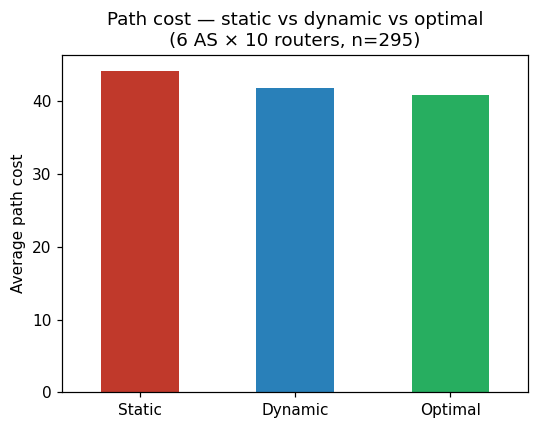

In [ ]:
summary = cost_df[["static_cost", "dynamic_cost", "optimal_cost"]].mean()
print(summary)
print(f"\nAvg cost saving (static vs dynamic): {cost_df['savings_pct'].mean():.2f}%")
print(f"Avg path stretch — static:  {cost_df['stretch_static'].mean():.3f}")
print(f"Avg path stretch — dynamic: {cost_df['stretch_dynamic'].mean():.3f}")
print(f"Avg reroutes per packet:    {cost_df['reroutes'].mean():.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
summary.plot(kind='bar', ax=ax, color=['#c0392b', '#2980b9', '#27ae60'])
ax.set_ylabel('Average path cost')
ax.set_title(f'Path cost — static vs dynamic vs optimal\n({NUM_AS} AS × {ROUTERS_PER_AS} routers, n={len(cost_df)})')
ax.set_xticklabels(['Static', 'Dynamic', 'Optimal'], rotation=0)
plt.tight_layout()
plt.show()


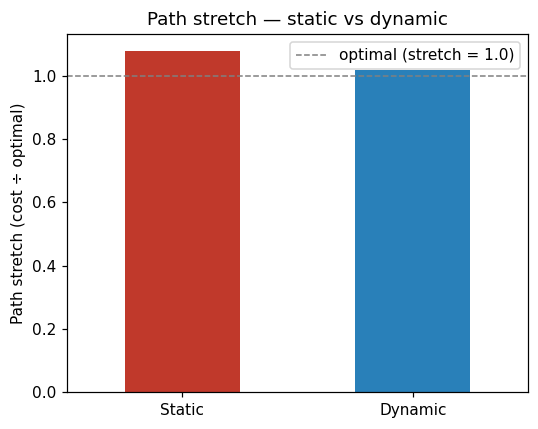

Avg path stretch — static:  1.078
Avg path stretch — dynamic: 1.017
Difference in path stretch: -0.061
Avg reroutes per packet:    0.52
Avg weight changes per packet: 10.61


In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
cost_df[["stretch_static", "stretch_dynamic"]].mean().plot(kind='bar', ax=ax, color=['#c0392b', '#2980b9'])
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='optimal (stretch = 1.0)')
ax.set_ylabel('Path stretch (cost ÷ optimal)')
ax.set_title('Path stretch — static vs dynamic')
ax.set_xticklabels(['Static', 'Dynamic'], rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Avg path stretch — static:  {cost_df['stretch_static'].mean():.3f}")
print(f"Avg path stretch — dynamic: {cost_df['stretch_dynamic'].mean():.3f}")
print(f"Difference in path stretch: {cost_df['stretch_dynamic'].mean() - cost_df['stretch_static'].mean():.3f}")
print(f"Avg reroutes per packet:    {cost_df['reroutes'].mean():.2f}")
print(f"Avg weight changes per packet: {cost_df['weight_changes'].mean():.2f}")

## 3. Cost savings vs. churn intensity

Sweeps the weight-change intensity multiplier (0× = no churn at all, 1× =
default, 2× = double the cascading probabilities) and reports the average
cost saving (%) at each level.


In [14]:
INTENSITY_TRIALS = 150   # "cycles" per intensity level
intensities = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10]

intensity_rows = []
random.seed(7)
for m in intensities:
    set_change_intensity(m)
    res = [r for r in (run_trial_cost(NUM_AS, ROUTERS_PER_AS) for _ in range(INTENSITY_TRIALS)) if r]
    intensity_rows.append({
        "intensity": m,
        "avg_savings_pct": stats.mean(r['savings_pct'] for r in res),
        "trials": len(res),
    })
reset_change_intensity()

intensity_df = pd.DataFrame(intensity_rows)
intensity_df


,intensity,avg_savings_pct,trials
0,0.0,0.000000,150
1,0.5,0.727258,150
2,1.0,3.066323,148
3,1.5,3.006440,150
4,2.0,3.293466,147
5,3.0,4.506804,150
6,5.0,4.387622,148
7,10.0,6.032193,145


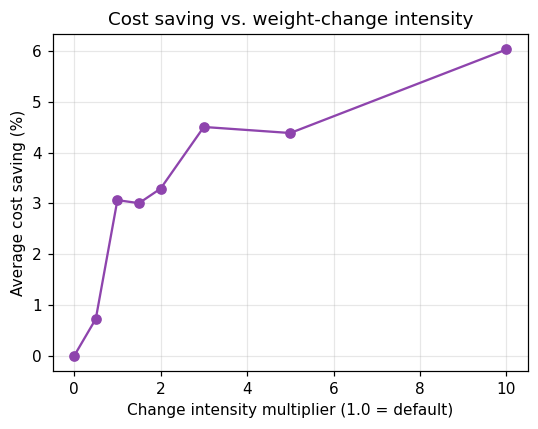

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(intensity_df['intensity'], intensity_df['avg_savings_pct'], marker='o', color='#8e44ad')
ax.set_xlabel('Change intensity multiplier (1.0 = default)')
ax.set_ylabel('Average cost saving (%)')
ax.set_title('Cost saving vs. weight-change intensity')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Delivery ratio under link failures

Models a per-hop transmission failure probability `p_fail`: each time a
packet attempts to cross a link, it is dropped with probability `p_fail`.

- **Static** never adapts — any dropped link along its fixed path fails the
  whole delivery.
- **Dynamic** notices the failed attempt, temporarily excludes that edge,
  reconverges (`setup_bgp`), and tries again (up to `MAX_RETRIES` times per
  hop) before giving up.


In [18]:
def attempt_dynamic_hop(routers, topo, prefixes, current_id, dst, dst_ip, p_fail, max_retries):
    removed = []
    result = None
    try:
        candidate = routers[current_id].get_next_hop(dst_ip, dst)
        attempts = 0
        while attempts <= max_retries:
            if candidate is None:
                break
            if random.random() >= p_fail:
                result = candidate
                break
            # this attempt failed -> temporarily exclude the edge and reconverge
            if topo.graph.has_edge(current_id, candidate):
                w = topo.graph[current_id][candidate]['weight']
                topo.graph.remove_edge(current_id, candidate)
                removed.append((current_id, candidate, w))
            setup_bgp(routers, topo, prefixes)
            candidate = routers[current_id].get_next_hop(dst_ip, dst)
            attempts += 1
    except Exception:
        # e.g. removing an edge disconnected an AS entirely (NodeNotFound) ->
        # no route is available, which is a legitimate failure outcome
        result = None
    finally:
        restored = False
        for u, v, w in removed:
            if not topo.graph.has_edge(u, v):
                topo.graph.add_edge(u, v, weight=w)
                restored = True
        if restored:
            try:
                setup_bgp(routers, topo, prefixes)
            except Exception:
                pass
    return result


def run_delivery_trial(num_as, routers_per_as, p_fail, max_retries=4):
    topo, routers, prefixes = build_topology(num_as, routers_per_as)
    router_ids = list(routers.keys())
    src, dst = random.sample(router_ids, 2)
    dst_router = routers[dst]

    static_path = compute_full_path(src, dst, routers, topo)
    static_delivered = True
    for u, v in zip(static_path[:-1], static_path[1:]):
        if random.random() < p_fail:
            static_delivered = False
            break

    dynamic_delivered = True
    current_id = src
    visited = {src}
    hops = 0
    while current_id != dst and hops < MAX_HOPS:
        nxt = attempt_dynamic_hop(routers, topo, prefixes, current_id, dst, dst_router.ip_address, p_fail, max_retries)
        if nxt is None or nxt in visited:
            dynamic_delivered = False
            break
        current_id = nxt
        visited.add(current_id)
        hops += 1
    if current_id != dst:
        dynamic_delivered = False

    return static_delivered, dynamic_delivered


In [ ]:
# ── Parameters ──
DELIVERY_TRIALS = 150   # "cycles" per failure level
MAX_RETRIES = 4

# We have 6 AS and 10 routers per AS

p_fail_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

delivery_rows = []
random.seed(11)
for p in p_fail_values:
    outcomes = [run_delivery_trial(NUM_AS, ROUTERS_PER_AS, p, MAX_RETRIES) for _ in range(DELIVERY_TRIALS)]
    static_ratio = 100 * sum(1 for s, d in outcomes if s) / len(outcomes)
    dynamic_ratio = 100 * sum(1 for s, d in outcomes if d) / len(outcomes)
    delivery_rows.append({"p_fail": p, "static_delivery_pct": static_ratio, "dynamic_delivery_pct": dynamic_ratio})

delivery_df = pd.DataFrame(delivery_rows)
delivery_df


,p_fail,static_delivery_pct,dynamic_delivery_pct
0,0.0,100.000000,100.000000
1,0.1,52.666667,70.000000
2,0.2,26.000000,49.333333
3,0.3,18.666667,30.000000
4,0.4,12.666667,20.000000
5,0.5,6.000000,12.666667


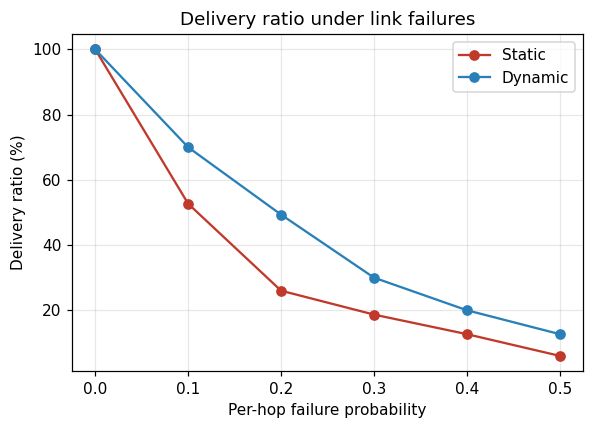

In [20]:

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(delivery_df['p_fail'], delivery_df['static_delivery_pct'], marker='o', label='Static', color='#c0392b')
ax.plot(delivery_df['p_fail'], delivery_df['dynamic_delivery_pct'], marker='o', label='Dynamic', color='#2980b9')
ax.set_xlabel('Per-hop failure probability')
ax.set_ylabel('Delivery ratio (%)')
ax.set_title('Delivery ratio under link failures')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


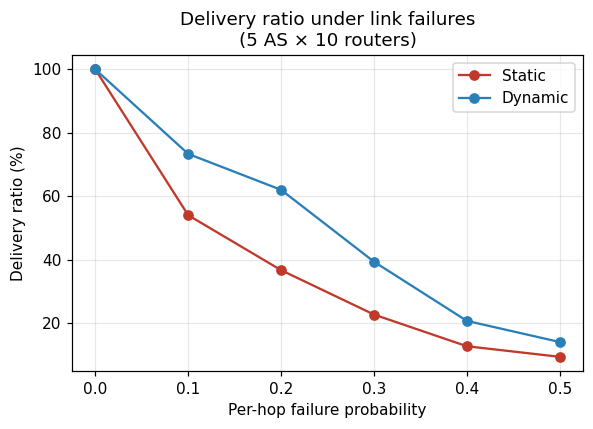

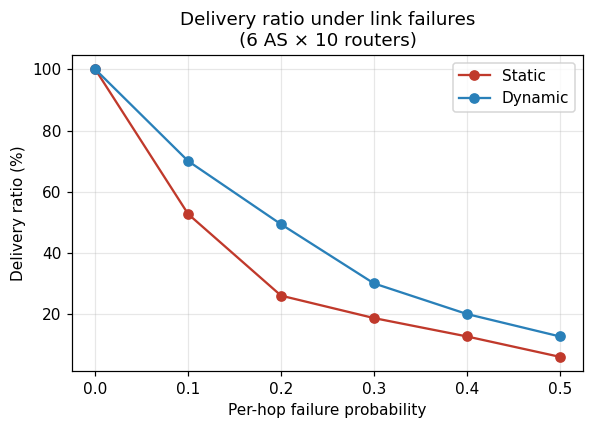

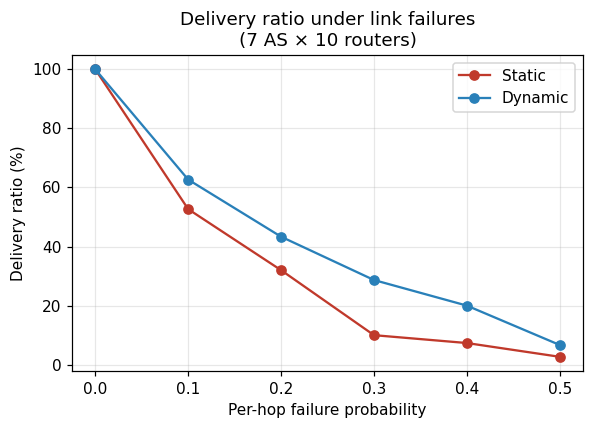

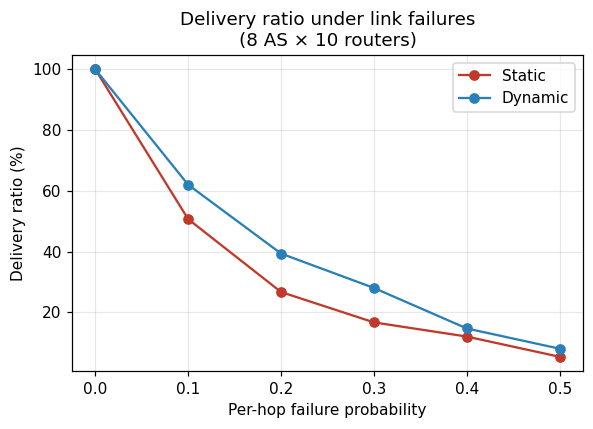

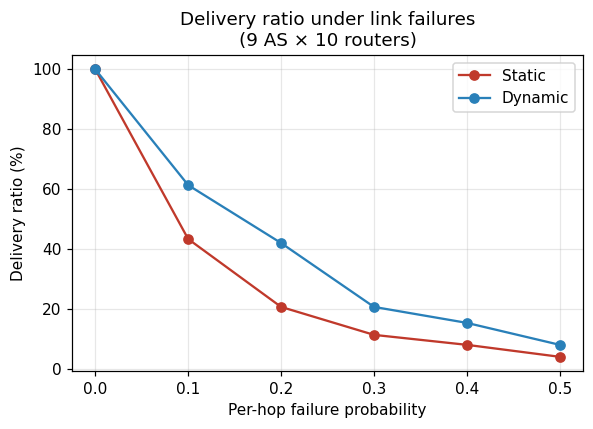

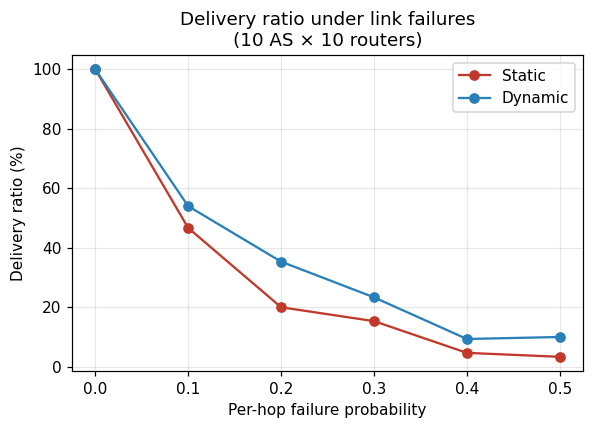

KeyboardInterrupt: 

In [21]:
# NUMBER OF AS CHANGED
DELIVERY_TRIALS = 150   # "cycles" per failure level
MAX_RETRIES = 4

# Change size of topology, so that the dynamic approach has more opportunities to reroute and recover from failures
as_size = [5 , 6 , 7 , 8 , 9 , 10]

for NUM_AS in as_size:
    delivery_rows = []
    random.seed(11)
    for p in p_fail_values:
        outcomes = [run_delivery_trial(NUM_AS, ROUTERS_PER_AS, p, MAX_RETRIES) for _ in range(DELIVERY_TRIALS)]
        static_ratio = 100 * sum(1 for s, d in outcomes if s) / len(outcomes)
        dynamic_ratio = 100 * sum(1 for s, d in outcomes if d) / len(outcomes)
        delivery_rows.append({"p_fail": p, "static_delivery_pct": static_ratio, "dynamic_delivery_pct": dynamic_ratio})

    delivery_df = pd.DataFrame(delivery_rows)

    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.plot(delivery_df['p_fail'], delivery_df['static_delivery_pct'], marker='o', label='Static', color='#c0392b')
    ax.plot(delivery_df['p_fail'], delivery_df['dynamic_delivery_pct'], marker='o', label='Dynamic', color='#2980b9')
    ax.set_xlabel('Per-hop failure probability')
    ax.set_ylabel('Delivery ratio (%)')
    ax.set_title(f'Delivery ratio under link failures\n({NUM_AS} AS × {ROUTERS_PER_AS} routers)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

p_fail_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

delivery_rows = []
random.seed(11)
for p in p_fail_values:
    outcomes = [run_delivery_trial(NUM_AS, ROUTERS_PER_AS, p, MAX_RETRIES) for _ in range(DELIVERY_TRIALS)]
    static_ratio = 100 * sum(1 for s, d in outcomes if s) / len(outcomes)
    dynamic_ratio = 100 * sum(1 for s, d in outcomes if d) / len(outcomes)
    delivery_rows.append({"p_fail": p, "static_delivery_pct": static_ratio, "dynamic_delivery_pct": dynamic_ratio})

delivery_df = pd.DataFrame(delivery_rows)
delivery_df


Even tho we have more AS, the differences in Delivery Ratio stay the same. Reason: For the AS we only create a RING-TOPOLOGY -> no random links. Change the number of Routers per AS to see bigger difference!

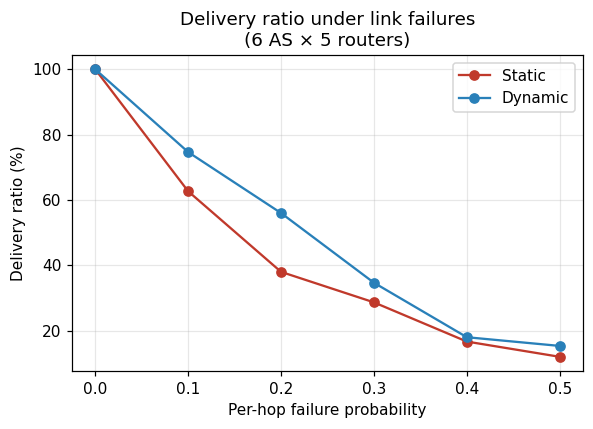

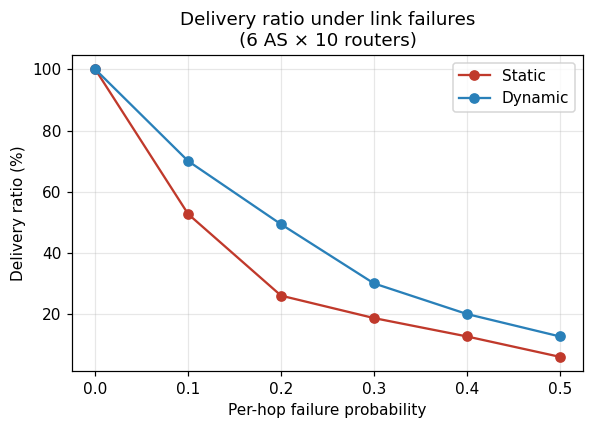

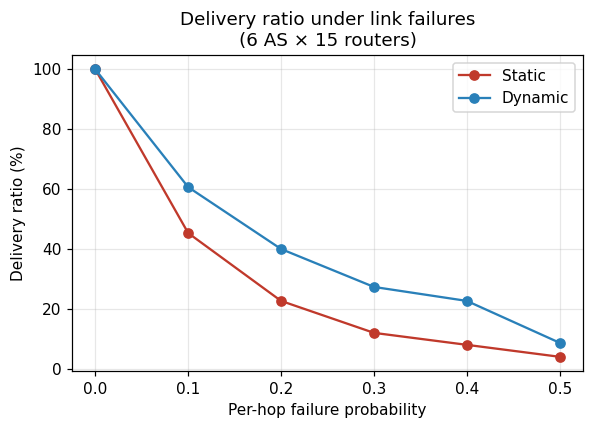

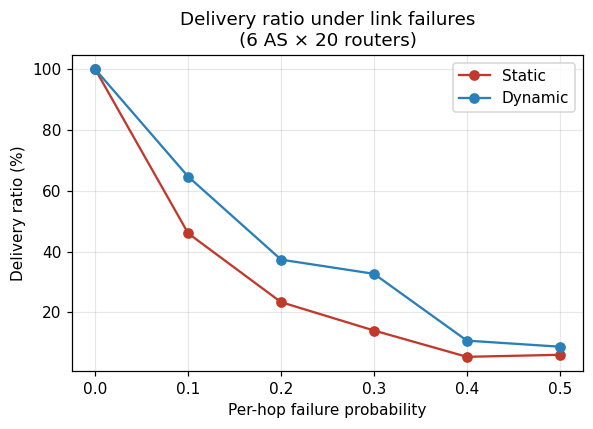

,p_fail,static_delivery_pct,dynamic_delivery_pct
0,0.0,100.000000,100.000000
1,0.1,46.000000,64.666667
2,0.2,23.333333,37.333333
3,0.3,14.000000,32.666667
4,0.4,5.333333,10.666667
5,0.5,6.000000,8.666667


In [23]:
# NUMBER OF AS CHANGED
DELIVERY_TRIALS = 150   # "cycles" per failure level
MAX_RETRIES = 4
NUM_AS = 6
# Change size of topology, so that the dynamic approach has more opportunities to reroute and recover from failures
num_routers_per_as = [5 , 10 , 15 , 20]

for ROUTERS_PER_AS in num_routers_per_as:
    delivery_rows = []
    random.seed(11)
    for p in p_fail_values:
        outcomes = [run_delivery_trial(NUM_AS, ROUTERS_PER_AS, p, MAX_RETRIES) for _ in range(DELIVERY_TRIALS)]
        static_ratio = 100 * sum(1 for s, d in outcomes if s) / len(outcomes)
        dynamic_ratio = 100 * sum(1 for s, d in outcomes if d) / len(outcomes)
        delivery_rows.append({"p_fail": p, "static_delivery_pct": static_ratio, "dynamic_delivery_pct": dynamic_ratio})

    delivery_df = pd.DataFrame(delivery_rows)

    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.plot(delivery_df['p_fail'], delivery_df['static_delivery_pct'], marker='o', label='Static', color='#c0392b')
    ax.plot(delivery_df['p_fail'], delivery_df['dynamic_delivery_pct'], marker='o', label='Dynamic', color='#2980b9')
    ax.set_xlabel('Per-hop failure probability')
    ax.set_ylabel('Delivery ratio (%)')
    ax.set_title(f'Delivery ratio under link failures\n({NUM_AS} AS × {ROUTERS_PER_AS} routers)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

p_fail_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

delivery_rows = []
random.seed(11)
for p in p_fail_values:
    outcomes = [run_delivery_trial(NUM_AS, ROUTERS_PER_AS, p, MAX_RETRIES) for _ in range(DELIVERY_TRIALS)]
    static_ratio = 100 * sum(1 for s, d in outcomes if s) / len(outcomes)
    dynamic_ratio = 100 * sum(1 for s, d in outcomes if d) / len(outcomes)
    delivery_rows.append({"p_fail": p, "static_delivery_pct": static_ratio, "dynamic_delivery_pct": dynamic_ratio})

delivery_df = pd.DataFrame(delivery_rows)
delivery_df


## 5. Computational overhead

Dijkstra recomputations and wall-clock runtime per trial — the price paid
for dynamic's adaptivity. Uses the `cost_results` from Section 2 for the
per-packet counts, then sweeps network size to show how runtime scales.


Avg Dijkstra calls — static (one-shot plan):     4.54
Avg Dijkstra calls — dynamic (live + reconverge): 2181.69
Avg runtime per dynamic trial: 117.95 ms


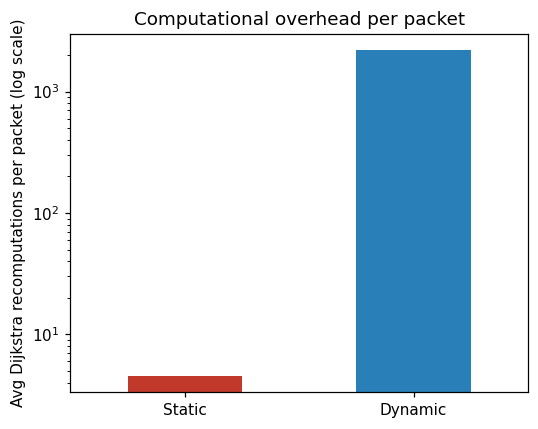

In [ ]:
print(f"Avg Dijkstra calls — static (one-shot plan):     {cost_df['static_dijkstra_calls'].mean():.2f}")
print(f"Avg Dijkstra calls — dynamic (live + reconverge): {cost_df['dynamic_dijkstra_calls'].mean():.2f}")
print(f"Avg runtime per dynamic trial: {cost_df['runtime_ms'].mean():.2f} ms")

fig, ax = plt.subplots(figsize=(5, 4))
cost_df[["static_dijkstra_calls", "dynamic_dijkstra_calls"]].mean().plot(
    kind='bar', ax=ax, color=['#c0392b', '#2980b9'], logy=True)
ax.set_ylabel('Avg Dijkstra recomputations per packet (log scale)')
ax.set_xticklabels(['Static', 'Dynamic'], rotation=0)
ax.set_title('Computational overhead per packet')
plt.tight_layout()
plt.show()


In [ ]:
# ── Runtime vs. network size ──
SIZE_TRIALS = 40   # "cycles" per size
sizes = [(3, 5), (4, 6), (5, 8), (6, 10), (8, 10)]

size_rows = []
random.seed(23)
reset_change_intensity()
for num_as, routers_per_as in sizes:
    res = [r for r in (run_trial_cost(num_as, routers_per_as) for _ in range(SIZE_TRIALS)) if r]
    size_rows.append({
        "num_as": num_as,
        "total_routers": num_as * routers_per_as,
        "avg_runtime_ms": stats.mean(r['runtime_ms'] for r in res),
        "avg_dynamic_dijkstra_calls": stats.mean(r['dynamic_dijkstra_calls'] for r in res),
        "trials": len(res),
    })

size_df = pd.DataFrame(size_rows)
size_df


,num_as,total_routers,avg_runtime_ms,avg_dynamic_dijkstra_calls,trials
0,3,15,4.565696,134.897436,39
1,4,24,15.442096,412.394737,38
2,5,40,39.809186,878.175000,40
3,6,60,108.132542,1966.100000,40
4,8,80,274.188006,4738.131579,38


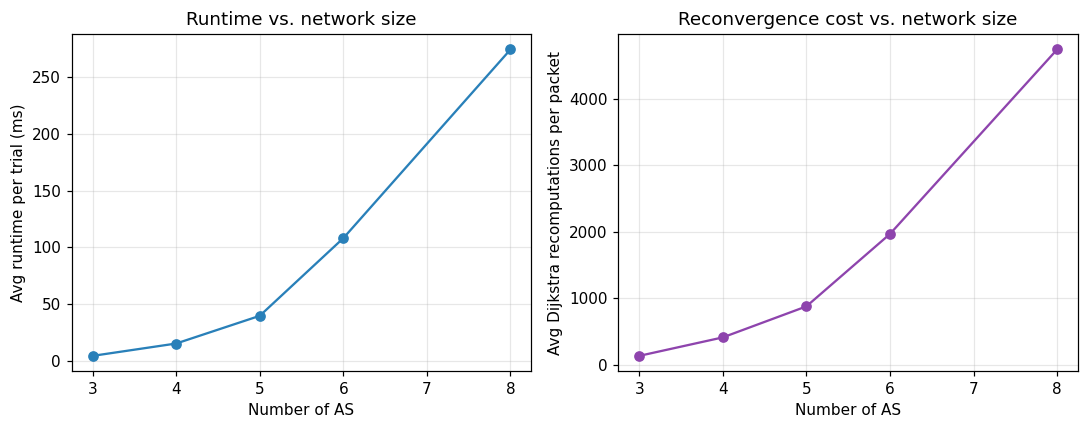

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(size_df['num_as'], size_df['avg_runtime_ms'], marker='o', color='#2980b9')
axes[0].set_xlabel('Number of AS')
axes[0].set_ylabel('Avg runtime per trial (ms)')
axes[0].set_title('Runtime vs. network size')
axes[0].grid(alpha=0.3)

axes[1].plot(size_df['num_as'], size_df['avg_dynamic_dijkstra_calls'], marker='o', color='#8e44ad')
axes[1].set_xlabel('Number of AS')
axes[1].set_ylabel('Avg Dijkstra recomputations per packet')
axes[1].set_title('Reconvergence cost vs. network size')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Summary table for the paper

A compact table pulling together the headline numbers from all sections
above, ready to drop into the *Experimental Results* section.


In [25]:
summary_table = pd.DataFrame([{
    "topology": f"{NUM_AS} AS × {ROUTERS_PER_AS} routers",
    "trials": len(cost_df),
    "static_cost": cost_df['static_cost'].mean(),
    "dynamic_cost": cost_df['dynamic_cost'].mean(),
    "optimal_cost": cost_df['optimal_cost'].mean(),
    "cost_saving_pct": cost_df['savings_pct'].mean(),
    "stretch_static": cost_df['stretch_static'].mean(),
    "stretch_dynamic": cost_df['stretch_dynamic'].mean(),
    "reroutes_per_packet": cost_df['reroutes'].mean(),
    "dijkstra_calls_static": cost_df['static_dijkstra_calls'].mean(),
    "dijkstra_calls_dynamic": cost_df['dynamic_dijkstra_calls'].mean(),
    "runtime_ms": cost_df['runtime_ms'].mean(),
}]).T.rename(columns={0: "value"})

summary_table


,value
topology,6 AS × 20 routers
trials,295
static_cost,44.186441
dynamic_cost,41.840678
optimal_cost,40.854237
cost_saving_pct,3.510205
stretch_static,1.077657
stretch_dynamic,1.016751
reroutes_per_packet,0.522034
dijkstra_calls_static,4.542373


In [24]:
# Optionally save everything for the paper's appendix / figures
cost_df.to_csv("results_path_cost.csv", index=False)
intensity_df.to_csv("results_churn_intensity.csv", index=False)
delivery_df.to_csv("results_delivery_ratio.csv", index=False)
size_df.to_csv("results_network_size.csv", index=False)
summary_table.to_csv("results_summary.csv")
print("Saved: results_path_cost.csv, results_churn_intensity.csv, results_delivery_ratio.csv, "
      "results_network_size.csv, results_summary.csv")


NameError: name 'size_df' is not defined